In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv('/Users/veron/Desktop/predicting_credit_card_payment/data/raw/UCI_Credit_Card.csv')

In [25]:
pd.set_option('display.max_columns', None)

In [26]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,SEP_REPAY_STATUS,AUG_REPAY_STATUS,JUL_REPAY_STATUS,JUN_REPAY_STATUS,MAY_REPAY_STATUS,APR_REPAY_STATUS,SEP_BILL_AMT,AUG_BILL_AMT,JUL_BILL_AMT,JUN_BILL_AMT,MAY_BILL_AMT,APR_BILL_AMT,SEP_PAY_AMT,AUG_PAY_AMT,JUL_PAY_AMT,JUN_PAY_AMT,MAY_PAY_AMT,APR_PAY_AMT,default.payment.next.month,AGE_GROUP,EDUCATION_LEVEL,MARRIAGE_DESC,LIMIT_BIN
0,1,20000.0,2,2,1,24,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1,Youth,University,Married,Q1
1,2,120000.0,2,2,2,26,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1,Adults,University,Single,Q3
2,3,90000.0,2,2,2,34,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0,Adults,University,Single,Q2
3,4,50000.0,2,2,1,37,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0,Adults,University,Married,Q1
4,5,50000.0,1,2,1,57,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0,Adults,University,Married,Q1


In [4]:
df = df.rename(columns = {
    "PAY_0": "SEP_REPAY_STATUS",
    "PAY_2": "AUG_REPAY_STATUS", 
    "PAY_3": "JUL_REPAY_STATUS",
    "PAY_4": "JUN_REPAY_STATUS",
    "PAY_5": "MAY_REPAY_STATUS",
    "PAY_6": "APR_REPAY_STATUS",

    "BILL_AMT1": "SEP_BILL_AMT",
    "BILL_AMT2": "AUG_BILL_AMT",
    "BILL_AMT3": "JUL_BILL_AMT",
    "BILL_AMT4": "JUN_BILL_AMT",
    "BILL_AMT5": "MAY_BILL_AMT",
    "BILL_AMT6": "APR_BILL_AMT",

    "PAY_AMT1": "SEP_PAY_AMT",
    "PAY_AMT2": "AUG_PAY_AMT",
    "PAY_AMT3": "JUL_PAY_AMT",
    "PAY_AMT4": "JUN_PAY_AMT",
    "PAY_AMT5": "MAY_PAY_AMT",
    "PAY_AMT6": "APR_PAY_AMT",
    })

In [27]:
df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,SEP_REPAY_STATUS,AUG_REPAY_STATUS,JUL_REPAY_STATUS,JUN_REPAY_STATUS,MAY_REPAY_STATUS,APR_REPAY_STATUS,SEP_BILL_AMT,AUG_BILL_AMT,JUL_BILL_AMT,JUN_BILL_AMT,MAY_BILL_AMT,APR_BILL_AMT,SEP_PAY_AMT,AUG_PAY_AMT,JUL_PAY_AMT,JUN_PAY_AMT,MAY_PAY_AMT,APR_PAY_AMT,default.payment.next.month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.842267,1.557267,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,-0.291100,51223.330900,49179.075167,4.701315e+04,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.744494,0.521405,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,1.149988,73635.860576,71173.768783,6.934939e+04,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,1.000000,1.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-165580.000000,-69777.000000,-1.572640e+05,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,3558.750000,2984.750000,2.666250e+03,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,22381.500000,21200.000000,2.008850e+04,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67091.000000,64006.250000,6.016475e+04,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,4.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,964511.000000,983931.000000,1.664089e+06,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [6]:
#The common reading is that -2 means no balance that month and 0 means they carried a balance and paid the minimum.
cols_pay = ['SEP_REPAY_STATUS', 'AUG_REPAY_STATUS', 'JUL_REPAY_STATUS',
       'JUN_REPAY_STATUS', 'MAY_REPAY_STATUS', 'APR_REPAY_STATUS']
for col in cols_pay:
    print(df[col].value_counts())

SEP_REPAY_STATUS
 0    14737
-1     5686
 1     3688
-2     2759
 2     2667
 3      322
 4       76
 5       26
 8       19
 6       11
 7        9
Name: count, dtype: int64
AUG_REPAY_STATUS
 0    15730
-1     6050
 2     3927
-2     3782
 3      326
 4       99
 1       28
 5       25
 7       20
 6       12
 8        1
Name: count, dtype: int64
JUL_REPAY_STATUS
 0    15764
-1     5938
-2     4085
 2     3819
 3      240
 4       76
 7       27
 6       23
 5       21
 1        4
 8        3
Name: count, dtype: int64
JUN_REPAY_STATUS
 0    16455
-1     5687
-2     4348
 2     3159
 3      180
 4       69
 7       58
 5       35
 6        5
 1        2
 8        2
Name: count, dtype: int64
MAY_REPAY_STATUS
 0    16947
-1     5539
-2     4546
 2     2626
 3      178
 4       84
 7       58
 5       17
 6        4
 8        1
Name: count, dtype: int64
APR_REPAY_STATUS
 0    16286
-1     5740
-2     4895
 2     2766
 3      184
 4       49
 7       46
 6       19
 5       13
 8        2


In [7]:
cols_demo = ['SEX', 'EDUCATION', 'MARRIAGE']
for col in cols_demo:
    print(df[col].value_counts().sort_index())

SEX
1    11888
2    18112
Name: count, dtype: int64
EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64
MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64


In [8]:
df['EDUCATION'] = df['EDUCATION'].replace([0, 5, 6], 4)
df['EDUCATION'].value_counts().sort_index()

EDUCATION
1    10585
2    14030
3     4917
4      468
Name: count, dtype: int64

In [9]:
df['MARRIAGE'] = df['MARRIAGE'].replace(0, 3)
df['MARRIAGE'].value_counts().sort_index()

MARRIAGE
1    13659
2    15964
3      377
Name: count, dtype: int64

In [10]:
df[df.duplicated(subset=['ID'])]

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,SEP_REPAY_STATUS,AUG_REPAY_STATUS,JUL_REPAY_STATUS,JUN_REPAY_STATUS,...,JUN_BILL_AMT,MAY_BILL_AMT,APR_BILL_AMT,SEP_PAY_AMT,AUG_PAY_AMT,JUL_PAY_AMT,JUN_PAY_AMT,MAY_PAY_AMT,APR_PAY_AMT,default.payment.next.month


In [11]:
MISSED_PAYMENT_RATE = (df['default.payment.next.month']==1).sum() / df['default.payment.next.month'].count()
print('The percentage of clients who missed their payment:' +  ' ' + str(MISSED_PAYMENT_RATE * 100) + '%')

The percentage of clients who missed their payment: 22.12%


In [12]:
df.groupby('default.payment.next.month')['AGE'].mean()

default.payment.next.month
0    35.417266
1    35.725738
Name: AGE, dtype: float64

In [13]:
conditions = [
    (df['AGE'] <= 24),
    (df['AGE'] >= 25) & (df['AGE'] <= 64),
    (df['AGE'] >= 65)
]
choices = ['Youth', 'Adults', 'Seniors']
df['AGE_GROUP'] = np.select(conditions, choices, default='Adults')

In [14]:
conditions = [
    (df['EDUCATION'] == 1),
    (df['EDUCATION'] == 2),
    (df['EDUCATION'] == 3),
    (df['EDUCATION'] == 4)
]
choices = ['Graduate School', 'University', 'High School', 'Others']
df['EDUCATION_LEVEL'] = np.select(conditions, choices, default='University')

In [15]:
df.groupby('AGE_GROUP')['default.payment.next.month'].agg(['mean', 'count'])

,mean,count
AGE_GROUP,,
Adults,0.216063,27205
Seniors,0.254545,110
Youth,0.271881,2685


In [16]:
df.groupby('EDUCATION_LEVEL')['default.payment.next.month'].agg(['mean', 'count'])

,mean,count
EDUCATION_LEVEL,,
Graduate School,0.192348,10585
High School,0.251576,4917
Others,0.070513,468
University,0.237349,14030


In [17]:
conditions = [
    (df['MARRIAGE'] == 1),
    (df['MARRIAGE'] == 2),
    (df['MARRIAGE'] == 3)
]
choices = ['Married', 'Single', 'Others']
df['MARRIAGE_DESC'] = np.select(conditions, choices, default='Single')

In [18]:
df.groupby('MARRIAGE_DESC')['default.payment.next.month'].agg(['mean', 'count'])

,mean,count
MARRIAGE_DESC,,
Married,0.234717,13659
Others,0.236074,377
Single,0.209283,15964


In [19]:
labels = ['Q1', 'Q2', 'Q3', 'Q4', 'Q5']
df['LIMIT_BIN'] = pd.qcut(df['LIMIT_BAL'], 5, labels=labels)
df.groupby('LIMIT_BIN')['default.payment.next.month'].agg(['mean','count'])


,mean,count
LIMIT_BIN,,
Q1,0.317874,7676
Q2,0.257984,4822
Q3,0.198595,6123
Q4,0.168604,5421
Q5,0.137966,5958


In [20]:
df['LIMIT_BIN']

0        Q1
1        Q3
2        Q2
3        Q1
4        Q1
         ..
29995    Q4
29996    Q3
29997    Q1
29998    Q2
29999    Q1
Name: LIMIT_BIN, Length: 30000, dtype: category
Categories (5, str): ['Q1' < 'Q2' < 'Q3' < 'Q4' < 'Q5']

<Axes: title={'center': 'Default Rate by Limit Bin'}, xlabel='Limit Bin', ylabel='Default Rate'>

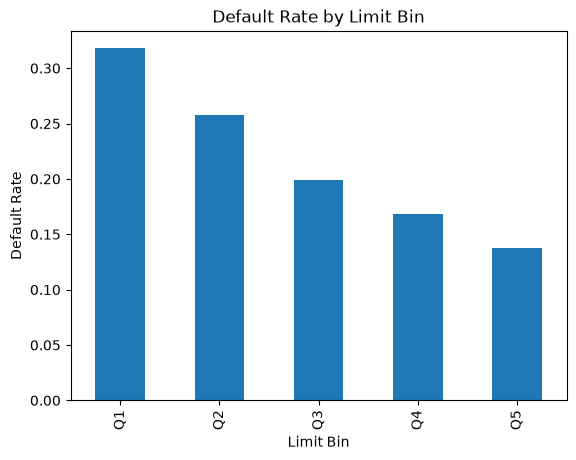

In [21]:
df.groupby('LIMIT_BIN')['default.payment.next.month'].mean().plot(title='Default Rate by Limit Bin', xlabel='Limit Bin', ylabel='Default Rate', kind='bar')

<Axes: title={'center': 'Default Rate by September Repay Statuses'}, xlabel='Repay Status', ylabel='Default Rate'>

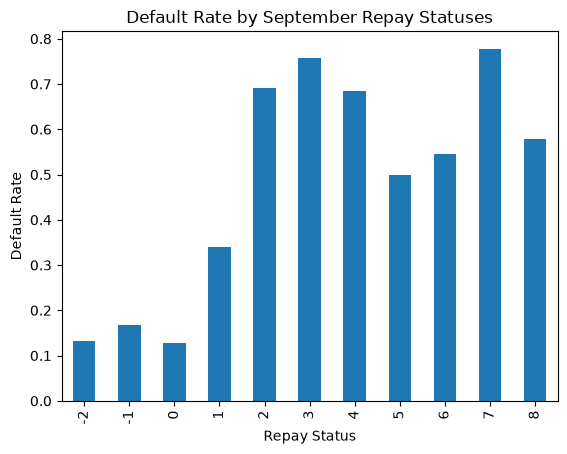

In [22]:
df.groupby('SEP_REPAY_STATUS')['default.payment.next.month'].mean().plot(kind='bar', title='Default Rate by September Repay Statuses', xlabel='Repay Status', ylabel='Default Rate')

In [23]:
df.groupby('SEP_REPAY_STATUS')['default.payment.next.month'].agg(['mean', 'count'])

,mean,count
SEP_REPAY_STATUS,,
-2,0.132294,2759
-1,0.167781,5686
0,0.128113,14737
1,0.339479,3688
2,0.691414,2667
3,0.757764,322
4,0.684211,76
5,0.500000,26
6,0.545455,11


In [24]:
df.to_csv('credit_card_cleaned.csv', index=False)